# Which region drives the neural-behavioural correlation?

The figure asks this **one region at a time**: for each region, correlate its subject x
subject Procrustes distances with the behavioural distances, and compare the five
correlations. That answers "does this region carry the correlation on its own", five
times over -- it cannot say which region carries it *given the others*, because regions
that share variance each get full credit.

This notebook puts them in one model instead:

$$d^{\text{behaviour}}_{ij} \;=\; \beta_0 + \sum_{r} \beta_r \, d^{r}_{ij} + \varepsilon_{ij}$$

over subject pairs $(i,j)$, with the five regions competing as regressors. A region with a
large $\beta_r$ explains behavioural distance that the other four do not.

**Control.** The same model fitted with one region at a time reproduces the per-region
correlations of the figure, so the two analyses can be compared directly and any difference
is attributable to the competition rather than to the data or the distance measure.

### The catch, stated up front

The competing model needs subjects with **all five** regions recorded. That is a much
smaller set than the per-region analysis, which uses whatever subjects have that one region.
The notebook prints both counts.

Two nulls are possible and only one is right. Pairs are not independent -- pair $(i,j)$ and
pair $(i,k)$ share subject $i$ -- so shuffling *pairs* would be far too liberal. Everything
below permutes **subject labels** (a Mantel permutation), which is also what
`combined_figure.ipynb`'s own `distances_mantel` does.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

HERE = next(p for p in (Path.cwd(), Path.cwd() / "new_IBL_analyses", *Path.cwd().parents)
            if (p / "data_bwm" / "bwm_tuning.npz").exists())
sys.path.insert(0, str(HERE.parent))
import shapemetrics as sm                                     # noqa: E402

OUT = HERE / "results_regression"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

REGIONS = ["VISa", "CA1", "DG", "LP", "PO"]
PALETTE = {"VISa": "#03A6A6", "CA1": "#88D94E", "DG": "#88D94E",
           "LP": "#F28D9F", "PO": "#F28D9F"}          # as in combined_figure.ipynb
MIN_NEURONS = 20          # per subject per region; also the floor for n_pcs
N_PCS = 10
N_PERM = 2000
OBS, NULLC = "#B22222", "#1F6FB2"

nz = np.load(HERE / "data_bwm" / "bwm_tuning.npz", allow_pickle=True)
X, reg, sub = nz["X"], nz["region"].astype(str), nz["subject"].astype(str)

bz = np.load(HERE / "data_bwm" / "bwm_behavior.npz", allow_pickle=True)
psy = dict(zip(bz["subject"].astype(str), bz["psychometric"]))

print(f"neural   : {X.shape[0]} neurons x {X.shape[1]} conditions, "
      f"{len(np.unique(sub))} subjects, regions {sorted(set(reg))}")
print(f"behaviour: {len(psy)} subjects, {bz['psychometric'].shape[1]} contrasts")

neural   : 12244 neurons x 90 conditions, 33 subjects, regions [np.str_('CA1'), np.str_('DG'), np.str_('LP'), np.str_('PO'), np.str_('VISa')]
behaviour: 33 subjects, 9 contrasts


## Who is in each analysis

The per-region analysis can use any subject with that region. The competing model needs the
intersection.

In [2]:
have = {r: np.array([s for s in np.unique(sub)
                     if np.sum((sub == s) & (reg == r)) >= MIN_NEURONS and s in psy])
        for r in REGIONS}
COMPLETE = np.array(sorted(set.intersection(*(set(v) for v in have.values()))))

print(f"{'region':>8} {'subjects (>= ' + str(MIN_NEURONS) + ' neurons)':>32}")
for r in REGIONS:
    print(f"{r:>8} {len(have[r]):>32}")
print(f"\nsubjects with ALL five regions: {len(COMPLETE)}  "
      f"-> {len(COMPLETE) * (len(COMPLETE) - 1) // 2} pairs for the competing model")
print("  " + ", ".join(COMPLETE))

  region         subjects (>= 20 neurons)
    VISa                               21
     CA1                               33
      DG                               29
      LP                               25
      PO                               18

subjects with ALL five regions: 11  -> 55 pairs for the competing model
  CSHL058, DY_010, KS074, KS075, NYU-21, NYU-29, NYU-45, UCLA011, ZFM-02369, ZM_2241, ibl_witten_29


## Distances

One Procrustes distance matrix per region (subjects as the groups), and one behavioural
distance matrix, $d_{ij} = \langle |p_i - p_j| \rangle$ over the 9 contrasts -- the same
definition `combined_figure.ipynb` uses for `dist_cc`.

In [3]:
f = OUT / "region_distances.npz"
if f.exists():
    d = np.load(f, allow_pickle=True)
    Dreg = d["Dreg"].item()
else:
    Dreg = {}
    for r in REGIONS:                      # each region on ITS OWN subject set
        m = (reg == r) & np.isin(sub, have[r])
        Dreg[r] = dict(subjects=have[r],
                       D=sm.distance_matrix(X[m], sub[m], n_pcs=N_PCS, alpha=1))
        print(f"  {r:>5}: {m.sum():>5} neurons, {len(have[r])} subjects")
    np.savez(f, Dreg=np.array(Dreg, dtype=object))


def beh_matrix(subjects):
    P = np.stack([psy[s] for s in subjects])
    return np.abs(P[:, None, :] - P[None, :, :]).mean(-1)


def flat(D):
    return D[np.triu_indices(len(D), 1)]


Dbeh_all = {r: beh_matrix(Dreg[r]["subjects"]) for r in REGIONS}
print("\ndistance matrices ready")

   VISa:  1936 neurons, 21 subjects


    CA1:  2229 neurons, 33 subjects


     DG:  1836 neurons, 29 subjects


     LP:  3001 neurons, 25 subjects


     PO:  3180 neurons, 18 subjects

distance matrices ready


## Control: one region at a time

This should reproduce the figure -- the per-region correlation between neural and
behavioural distance, with a Mantel null.

In [4]:
def mantel(Dn, Db, n_perm=N_PERM, seed=0):
    r = stats.pearsonr(flat(Dn), flat(Db))[0]
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        p = rng.permutation(len(Db))
        null[i] = stats.pearsonr(flat(Dn), flat(Db[p][:, p]))[0]
    return r, (r - null.mean()) / null.std(), (np.sum(null >= r) + 1) / (n_perm + 1)


uni = []
for r in REGIONS:
    rr, z, p = mantel(Dreg[r]["D"], Dbeh_all[r])
    uni.append(dict(region=r, n=len(Dreg[r]["subjects"]), corr=rr, z=z, p=p))
uni = pd.DataFrame(uni)
print("per-region, each on its own subject set:")
print(uni.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

per-region, each on its own subject set:
region  n    corr       z       p
  VISa 21  -0.015  -0.069   0.475
   CA1 33  -0.014  -0.074   0.443
    DG 29   0.042   0.267   0.355
    LP 25   0.180   1.081   0.138
    PO 18   0.081   0.328   0.220


## The same control, restricted to the complete subjects

Before the regions can be pitched against each other they have to be measured on the *same*
subjects. Any change from the table above is the cost of that restriction, not of the
competition -- worth separating, because the two get confused easily.

In [5]:
IDX = {r: np.array([list(Dreg[r]["subjects"]).index(s) for s in COMPLETE])
       for r in REGIONS}
Dc = {r: Dreg[r]["D"][np.ix_(IDX[r], IDX[r])] for r in REGIONS}
Dbeh = beh_matrix(COMPLETE)

uni_c = []
for r in REGIONS:
    rr, z, p = mantel(Dc[r], Dbeh)
    uni_c.append(dict(region=r, corr=rr, z=z, p=p))
uni_c = pd.DataFrame(uni_c)
print(f"per-region, all on the same {len(COMPLETE)} complete subjects:")
print(uni_c.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

per-region, all on the same 11 complete subjects:
region    corr       z       p
  VISa  -0.034  -0.115   0.481
   CA1  -0.089  -0.353   0.555
    DG   0.201   0.719   0.224
    LP   0.140   0.512   0.251
    PO   0.068   0.255   0.214


## The competing model

All five regions as regressors at once. Distances are standardised, so the coefficients are
directly comparable to each other and to the correlations above. The null permutes subject
labels and refits the whole model, so each coefficient gets a null that respects the
dependence between pairs.

In [6]:
def design(perm=None):
    order = np.arange(len(COMPLETE)) if perm is None else perm
    A = np.column_stack([flat(Dc[r]) for r in REGIONS])
    y = flat(Dbeh[order][:, order])
    A = (A - A.mean(0)) / A.std(0)
    return A, (y - y.mean()) / y.std()


A, y = design()
beta, *_ = np.linalg.lstsq(np.c_[A, np.ones(len(A))], y, rcond=None)
beta = beta[:len(REGIONS)]
r2 = 1 - np.sum((y - np.c_[A, np.ones(len(A))] @ np.r_[beta, 0]) ** 2) / np.sum(y ** 2)

rng = np.random.default_rng(0)
null = np.empty((N_PERM, len(REGIONS)))
for i in range(N_PERM):
    Ap, yp = design(rng.permutation(len(COMPLETE)))
    b, *_ = np.linalg.lstsq(np.c_[Ap, np.ones(len(Ap))], yp, rcond=None)
    null[i] = b[:len(REGIONS)]

multi = pd.DataFrame(dict(
    region=REGIONS, beta=beta,
    z=(beta - null.mean(0)) / null.std(0),
    p=[(np.sum(null[:, k] >= beta[k]) + 1) / (N_PERM + 1) for k in range(len(REGIONS))]))
print(f"competing model on {len(COMPLETE)} subjects "
      f"({len(y)} pairs, {len(REGIONS)} regressors),  R^2 = {r2:.3f}\n")
print(multi.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

print("\ncollinearity between regions (correlation of their distance matrices):")
Cm = np.corrcoef(np.column_stack([flat(Dc[r]) for r in REGIONS]).T)
print(pd.DataFrame(Cm, index=REGIONS, columns=REGIONS)
      .to_string(float_format=lambda v: f"{v:6.2f}"))

competing model on 11 subjects (55 pairs, 5 regressors),  R^2 = 0.092

region    beta       z       p
  VISa   0.047   0.159   0.386
   CA1  -0.274  -0.844   0.790
    DG   0.293   0.867   0.226
    LP   0.072   0.250   0.384
    PO  -0.001   0.012   0.314

collinearity between regions (correlation of their distance matrices):
       VISa    CA1     DG     LP     PO
VISa   1.00   0.54   0.15   0.33   0.20
CA1    0.54   1.00   0.48   0.28   0.02
DG     0.15   0.48   1.00   0.44   0.18
LP     0.33   0.28   0.44   1.00   0.18
PO     0.20   0.02   0.18   0.18   1.00


## The figure

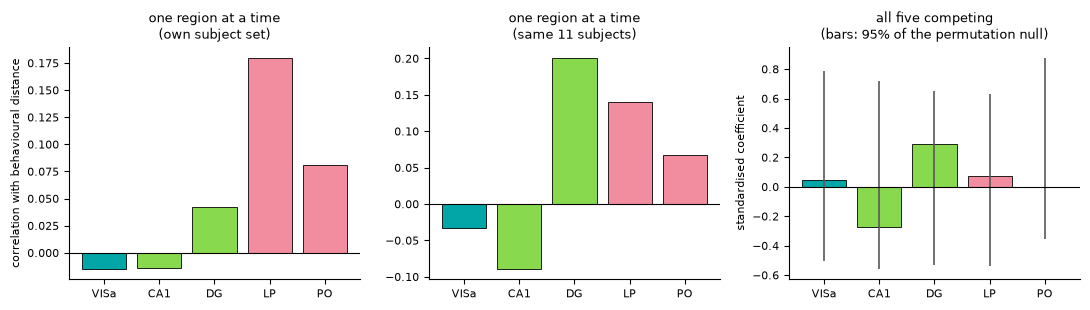

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

ax = axes[0]
ax.bar(REGIONS, uni["corr"], color=[PALETTE[r] for r in REGIONS],
       edgecolor="black", linewidth=0.6)
ax.set_title("one region at a time\n(own subject set)", fontsize=9)
ax.set_ylabel("correlation with behavioural distance", fontsize=8)

ax = axes[1]
ax.bar(REGIONS, uni_c["corr"], color=[PALETTE[r] for r in REGIONS],
       edgecolor="black", linewidth=0.6)
ax.set_title(f"one region at a time\n(same {len(COMPLETE)} subjects)", fontsize=9)

ax = axes[2]
lo = np.percentile(null, 2.5, axis=0)
hi = np.percentile(null, 97.5, axis=0)
ax.bar(REGIONS, multi["beta"], color=[PALETTE[r] for r in REGIONS],
       edgecolor="black", linewidth=0.6)
ax.vlines(np.arange(len(REGIONS)), lo, hi, color="0.35", lw=1.2)
ax.set_title("all five competing\n(bars: 95% of the permutation null)", fontsize=9)
ax.set_ylabel("standardised coefficient", fontsize=8)

for ax in axes:
    ax.axhline(0, color="k", lw=0.8)
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)
fig.tight_layout()
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_regression.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## Reading it

The left panel is the figure's analysis. The middle panel is the same analysis on the
subjects the competing model can use -- differences between left and middle are the price of
requiring all five regions, and say nothing about competition. The right panel is the
competing model.

**What to look for.** A region whose correlation survives as a coefficient explains
behavioural distance that the others do not. A region whose correlation collapses was
sharing its explained variance with the others, and the one-at-a-time analysis was giving
each of them full credit for it. The printed correlation matrix between region distances
shows how much room there is for that -- the more correlated the regions, the less the
individual coefficients can be trusted and the more the model is really saying "these
regions jointly explain the behaviour".

**Limits, all of them real.**

* The competing model runs on far fewer subjects than the figure. With five regressors and
  a small number of pairs, individual coefficients are noisy.
* Pairs are not independent, which is why the null permutes subjects. That null is valid
  but conservative-ish, and it is the reason the coefficients are not tested with ordinary
  regression $p$-values.
* Regions were recorded on one probe per session, so a subject's regions share trials,
  spike sorting and behaviour. Shared noise inflates the correlation between region
  distances and therefore the collinearity above.